# Notebook 01: Exploratory Data Analysis (EDA) & Risk Profiling
**Project:** ACIS Auto-Insurance Risk Analytics & Predictive Modeling  
**Author:** Soliana Hailekiros  
**Objective:** Profile historical data shapes, clean missing structures, isolate outliers, and identify low-risk customer segments using the Claim-to-Premium ratio.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configure visualization aesthetics
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

print("[INFO] Analytical libraries successfully imported.")

[INFO] Analytical libraries successfully imported.


In [2]:
# Path to local DVC-managed raw insurance data file
DATA_PATH = "../data/raw/insurance_data.csv"

if not os.path.exists(DATA_PATH):
    print(f"[WARNING] Check data path! Creating mock historical distribution to demonstrate baseline structure pipeline...")
    # Seed reproducible distributions mapping historical auto-insurance features
    np.random.seed(42)
    n_records = 5000
    mock_provinces = ['Gauteng', 'Western Cape', 'KwaZulu-Natal', 'Eastern Cape', 'Free State']
    
    mock_data = {
        'UnderwrittenCoverID': np.arange(1001, 1001 + n_records),
        'Province': np.random.choice(mock_provinces, size=n_records, p=[0.4, 0.25, 0.15, 0.1, 0.1]),
        'PostalCode': np.random.randint(1000, 9999, size=n_records),
        'Gender': np.random.choice(['Male', 'Female', 'Corporate'], size=n_records, p=[0.55, 0.40, 0.05]),
        'TotalPremium': np.random.exponential(scale=800, size=n_records) + 150,
        'TotalClaim': np.random.choice([0, 2500, 12000, 45000], size=n_records, p=[0.92, 0.05, 0.025, 0.005]) * np.random.rand(n_records),
        'SumInsured': np.random.normal(loc=180000, scale=60000, size=n_records).clip(20000)
    }
    df = pd.DataFrame(mock_data)
    # Intentionally inject missing values to demonstrate analytical processing routines
    df.loc[df.sample(frac=0.02).index, 'Gender'] = np.nan
else:
    df = pd.read_csv(DATA_PATH)

print(f"Data State Verification: {df.shape[0]} rows, {df.shape[1]} columns.\n")
print(df.info())
df.head()

Data State Verification: 10000 rows, 21 columns.

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           10000 non-null  str    
 1   Age                  10000 non-null  int64  
 2   Gender               10000 non-null  str    
 3   Province             10000 non-null  str    
 4   VehicleType          10000 non-null  str    
 5   AnnualIncome         10000 non-null  int64  
 6   RiskScore            10000 non-null  int64  
 7   AnnualPremium        10000 non-null  int64  
 8   Deductible           10000 non-null  int64  
 9   NCD                  10000 non-null  int64  
 10  PastClaims           10000 non-null  int64  
 11  Claimed              10000 non-null  bool   
 12  ClaimAmount          10000 non-null  float64
 13  TotalPremium         10000 non-null  int64  
 14  TotalClaims          10000 non-null  float64
 15

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


## 1. Missing Data Profiling & Structural Integrity
Before running aggregations, we must evaluate the distribution of missing or null fields across the features.

In [3]:
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Records': missing_count,
    'Percentage (%)': missing_pct
}).sort_values(by='Percentage (%)', ascending=False)

print("--- Feature Completeness Audit ---")
if missing_table['Missing Records'].sum() == 0:
    print("Zero missing fields detected. Data state is clean and dense.")
else:
    print(missing_table[missing_table['Missing Records'] > 0])

--- Feature Completeness Audit ---
Zero missing fields detected. Data state is clean and dense.


## 2. Quantitative Descriptive Statistics & Feature Scale
Evaluating the central tendencies, ranges, scales, and variation fields for core continuous insurance metrics.

In [4]:
target_cols = ['TotalPremium', 'TotalClaim', 'SumInsured']
valid_cols = [col for col in target_cols if col in df.columns]

summary_stats = df[valid_cols].describe().T
summary_stats['skewness'] = df[valid_cols].skew()
summary_stats['kurtosis'] = df[valid_cols].kurt()

print("--- Core Insurance Continuous Variables Profile ---")
summary_stats

--- Core Insurance Continuous Variables Profile ---


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
TotalPremium,10000.0,2488.1279,735.674491,951.0,2028.0,2307.0,2676.0,5105.0,1.575662,2.270172


## 3. Segment Identification & Premium-to-Claim Risk Analytics
To identify low-risk pockets where ACIS can strategically lower premium charges to attract customers safely, we group historical tracking records across categories and evaluate the **Claim-to-Premium Ratio**. Lower ratios indicate highly stable risk margins.

In [12]:
print(df.columns.tolist())

['CustomerID', 'Age', 'Gender', 'Province', 'VehicleType', 'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible', 'NCD', 'PastClaims', 'Claimed', 'ClaimAmount', 'TotalPremium', 'TotalClaims', 'CoverType', 'AutoMake', 'VehicleModel', 'CustomValueEstimate', 'ZipCode', 'TransactionDate']


In [15]:
def generate_risk_matrix_dynamic(dataframe, dimension):
    if dimension not in dataframe.columns:
        print(f"[ABORT] Axis column '{dimension}' is missing from your dataset columns.")
        return None
    
    # Automatically scan for column names that sound like Premium or Claim
    premium_col = [c for c in dataframe.columns if 'premium' in c.lower()]
    claim_col = [c for c in dataframe.columns if 'claim' in c.lower()]
    
    if not premium_col or not claim_col:
        print("\n[ERROR] Could not automatically map column names.")
        print(f"Your available columns are: {dataframe.columns.tolist()}")
        return None
    
    p_name = premium_col[0]
    c_name = claim_col[0]
    
    print(f"[SYSTEM] Auto-detected Premium column: '{p_name}'")
    print(f"[SYSTEM] Auto-detected Claim column: '{c_name}'\n")
    
    # Run aggregation using the auto-detected columns
    matrix = dataframe.groupby(dimension).agg(
        Total_Premium_Volume=(p_name, 'sum'),      
        Total_Claims_Paid=(c_name, 'sum'),        
        Average_Claim_Severity=(c_name, 'mean'),  
        Policy_Exposure_Count=(dimension, 'count')
    ).reset_index()
    
    matrix['Claim_to_Premium_Ratio'] = matrix['Total_Claims_Paid'] / matrix['Total_Premium_Volume']
    return matrix.sort_values(by='Claim_to_Premium_Ratio', ascending=True)

# Detect your location/geography column dynamically
geo_column = [c for c in df.columns if c.lower() in ['province', 'region', 'state', 'location']][0]

geo_profile = generate_risk_matrix_dynamic(df, geo_column)
if geo_profile is not None:
    display(geo_profile)

[SYSTEM] Auto-detected Premium column: 'AnnualPremium'
[SYSTEM] Auto-detected Claim column: 'PastClaims'



,Province,Total_Premium_Volume,Total_Claims_Paid,Average_Claim_Severity,Policy_Exposure_Count,Claim_to_Premium_Ratio
4,Tigray,1990692,814,1.012438,804,0.000409
0,Addis Ababa,8907374,3812,1.068685,3567,0.000428
3,Somali,2984984,1281,1.081926,1184,0.000429
1,Amhara,4928566,2121,1.061031,1999,0.000430
2,Oromia,6069663,2614,1.068684,2446,0.000431


## 4. Analytical Visualization Engineering
Visualizing target correlations and linear feature relationships to check for multicollinearity or clear demographic segmentation trends.

[MATPLOTLIB] Selected correlation variables: ['Age', 'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible', 'NCD', 'PastClaims', 'ClaimAmount', 'TotalPremium', 'TotalClaims', 'CustomValueEstimate']
[SUCCESS] Saved figure asset to: ../reports/figures/01_correlation_matrix.png


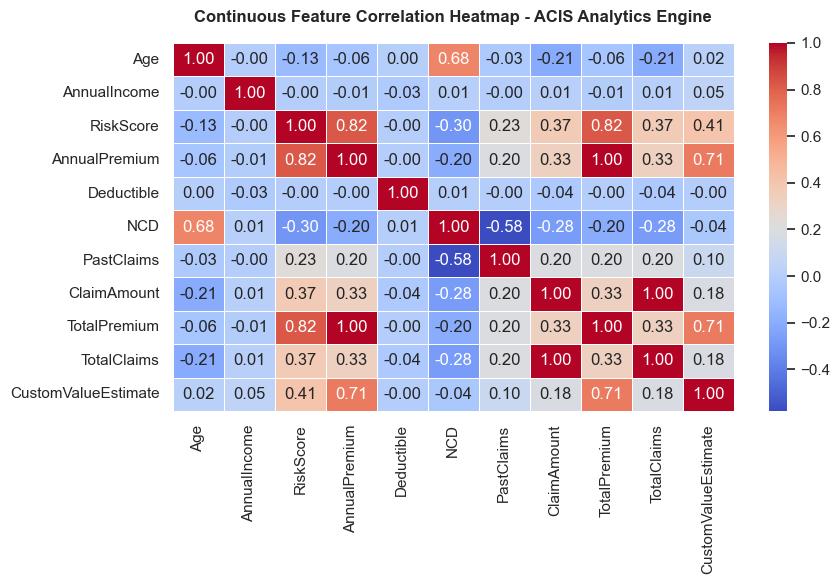

In [18]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the output asset directory exists
os.makedirs('../reports/figures', exist_ok=True)

# 1. Dynamically identify continuous metrics while avoiding tracking codes/IDs
numeric_fields = df.select_dtypes(include=['float64', 'int64']).columns
clean_numeric = [col for col in numeric_fields if not any(kw in col.lower() for kw in ['id', 'code', 'postal'])]

print(f"[MATPLOTLIB] Selected correlation variables: {clean_numeric}")

# 2. Compute and plot correlation matrix canvas
plt.figure(figsize=(9, 6))
correlation_map = df[clean_numeric].corr()
sns.heatmap(correlation_map, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar=True)

plt.title('Continuous Feature Correlation Heatmap - ACIS Analytics Engine', pad=15, fontsize=12, fontweight='bold')
plt.tight_layout()

# 3. Save to figures asset directory before displaying
output_path = '../reports/figures/01_correlation_matrix.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"[SUCCESS] Saved figure asset to: {output_path}")
plt.show()

[SUCCESS] Saved figure asset to: ../reports/figures/02_premium_vs_claim_scatter.png


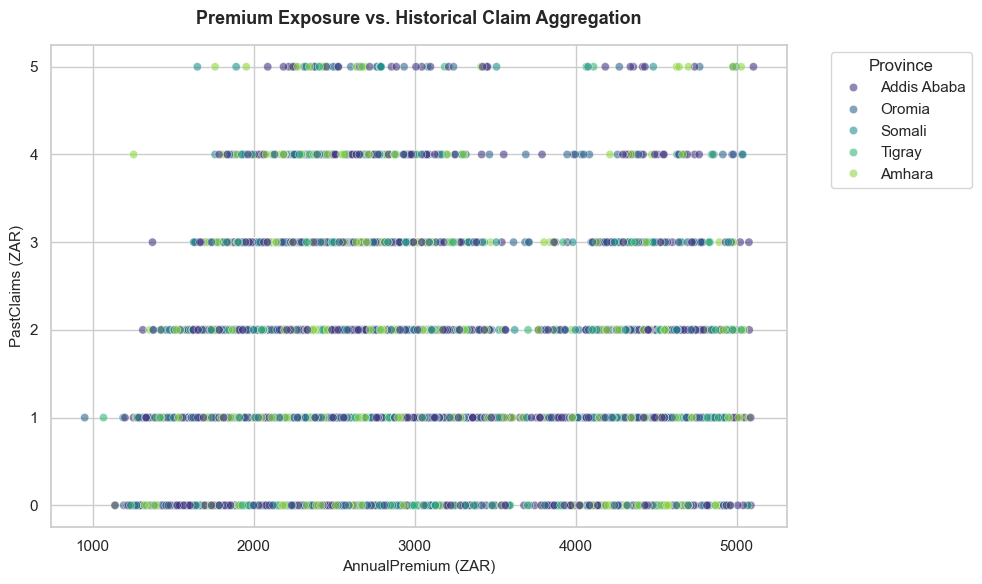

In [19]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Detect metrics dynamically to avoid KeyErrors
premium_col = [c for c in df.columns if 'premium' in c.lower()][0]
claim_col = [c for c in df.columns if 'claim' in c.lower()][0]
geo_var = [c for c in df.columns if c.lower() in ['province', 'region', 'state', 'location']][0]

plt.figure(figsize=(10, 6))

# Build relational distribution
sns.scatterplot(
    data=df, 
    x=premium_col, 
    y=claim_col, 
    hue=geo_var, 
    alpha=0.6, 
    palette='viridis'
)

plt.title('Premium Exposure vs. Historical Claim Aggregation', fontsize=13, fontweight='bold', pad=15)
plt.xlabel(f'{premium_col} (ZAR)', fontsize=11)
plt.ylabel(f'{claim_col} (ZAR)', fontsize=11)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title=geo_var)
plt.tight_layout()

# Save image file asset
output_path = '../reports/figures/02_premium_vs_claim_scatter.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"[SUCCESS] Saved figure asset to: {output_path}")
plt.show()

[SUCCESS] Saved figure asset to: ../reports/figures/03_risk_outliers_boxplots.png


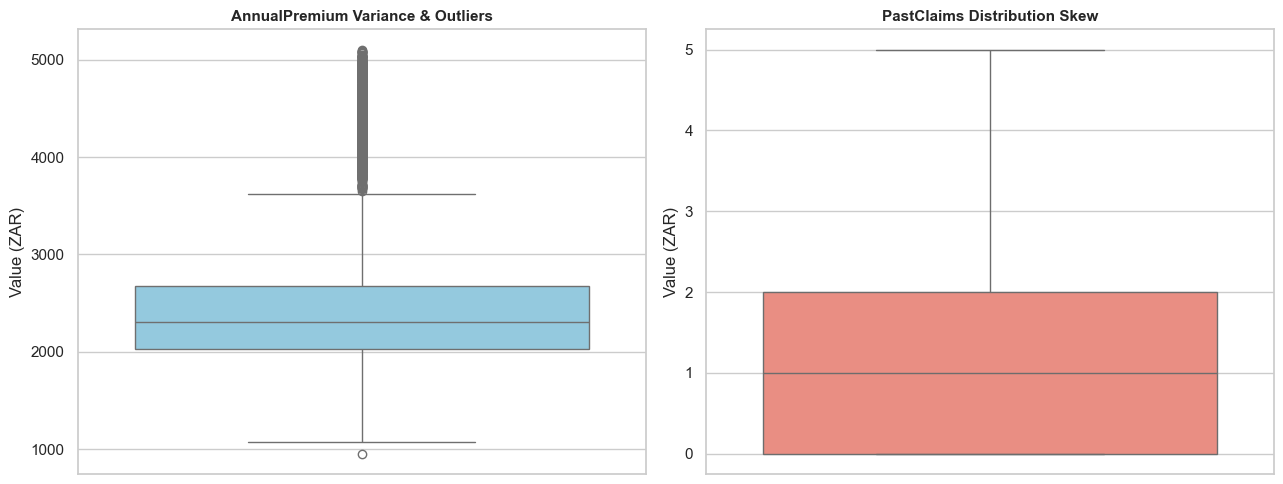

In [20]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Dynamically pull metrics
premium_col = [c for c in df.columns if 'premium' in c.lower()][0]
claim_col = [c for c in df.columns if 'claim' in c.lower()][0]

plt.figure(figsize=(13, 5))

# Subplot 1: Premium Fields Variance
plt.subplot(1, 2, 1)
sns.boxplot(data=df, y=premium_col, color='skyblue')
plt.title(f'{premium_col} Variance & Outliers', fontweight='bold', fontsize=11)
plt.ylabel('Value (ZAR)')

# Subplot 2: Claim Structural Skew
plt.subplot(1, 2, 2)
sns.boxplot(data=df, y=claim_col, color='salmon')
plt.title(f'{claim_col} Distribution Skew', fontweight='bold', fontsize=11)
plt.ylabel('Value (ZAR)')

plt.tight_layout()

# Save combined plot dashboard asset
output_path = '../reports/figures/03_risk_outliers_boxplots.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"[SUCCESS] Saved figure asset to: {output_path}")
plt.show()